# Theory Multi product model 
This notebook contains numerical results that can show when the pareto fronts between the three metrics is different.

## Structure
The data is prepared first by sampling from normal and gamma distributions with (negative) correlations. Then, the multi-product model is applied to the data and the same results are drawn such as the pareto front the land allocation fractions, and the forward contract sizes. 

## Algorithms
The algorithm as described in applied are also given here. for a better explanation, that notebook can be consulted. The cell is colapsed for conciseness of the notebook. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy  as cp
from tqdm.auto import tqdm

C:\Users\lbr476\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Multi-product CVPI optimization LSV ###

def r_from_credibility(Q, a_i):
    """
    r_i = F_Qi^{-1}(1 - a_i): the (1 - a_i)-quantile of the yield distribution,
    estimated nonparametrically from the observed sample of Q_i.
    P(Q_i >= r_i) ~= a_i   <=>   P(Q_i <= r_i) ~= 1 - a_i
    """
    return np.quantile(Q, 1.0 - a_i)


def Wbar_multi(b, q, PQbar_vec, Pbar_vec, f_vec):
    """E[W] for the multi-product model (linear in b, q)."""
    return np.sum(b * PQbar_vec) - np.sum(q * (Pbar_vec - f_vec))


def LSV_multi(b, q, A_mat, C_mat):
    """
    Sample lower semi-variance of W for given (b, q):
        LSV(b,q) = mean( max( sum_i [ b_i*A_ij - q_i*C_ij ], 0 )^2 )
    where A_ij = PQbar_i - P_ij*Q_ij and C_ij = Pbar_i - P_ij are the
    per-sample, per-crop analogues of the single-product a_j, b_j.
    """
    shortfall = A_mat @ b - C_mat @ q
    return np.mean(np.maximum(shortfall, 0.0) ** 2)


def CVPI_optimization_multi(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
    Multi-product LSV-minimizing optimization:

        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= sum_i (b_i*A_ij - q_i*C_ij)   (epigraph of the shortfall)
                   u_j >= 0
                   sum_i b_i = 1
                   q_i <= r_i * b_i                      for all i
                   b_i, q_i >= 0                         for all i
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m

    A_mat, C_mat            : (N, n) arrays, column i corresponds to crop i
    PQbar_vec, Pbar_vec,
    f_vec, r_vec             : length-n arrays
    """
    A_mat     = np.asarray(A_mat, dtype=float)
    C_mat     = np.asarray(C_mat, dtype=float)
    PQbar_vec = np.asarray(PQbar_vec, dtype=float)
    Pbar_vec  = np.asarray(Pbar_vec, dtype=float)
    f_vec     = np.asarray(f_vec, dtype=float)
    r_vec     = np.asarray(r_vec, dtype=float)

    N_, n_ = A_mat.shape

    # --- 1. Scale so the QP stays well conditioned (same idea as the single-product model) ---
    scale = np.median(np.abs(A_mat[A_mat != 0])) if np.any(A_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    A_s     = A_mat / scale
    C_s     = C_mat / scale
    PQbar_s = PQbar_vec / scale
    Pbar_s  = Pbar_vec / scale
    f_s     = f_vec / scale
    m_s     = m / scale

    # --- 2. Decision variables ---
    b = cp.Variable(n_, nonneg=True)   # land share per crop
    q = cp.Variable(n_, nonneg=True)   # forward-contracted quantity per crop
    u = cp.Variable(N_, nonneg=True)   # epigraph of the shortfall

    constraints = [
        u >= A_s @ b - C_s @ q,
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),                             # r_i * b_i >= q_i
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,                 # E[W] >= m
    ]

    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star = b.value
    q_star = q.value
    lsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)

    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b*            : {np.round(b_star, 4)}")
        print(f"q*            : {np.round(q_star, 4)}")
        print(f"LSV(b*,q*)    : {lsv_star:.4f}")
        print(f"E[W](b*,q*)   : {Wbar_star:.2f}  (must be >= m = {m})")

    return b_star, q_star, lsv_star, Wbar_star


### Analytical (Variance) multi-product optimization — active-set method ###
#
# Decision vector v = [b_1, ..., b_n, q_1, ..., q_n]: the first n entries are the
# land shares b_i, the last n entries are the forward-contract sizes q_i. Both
# W's expectation and its variance are linear/quadratic forms in this single
# stacked vector, so the whole model reduces to:
#     min_v  v^T Sigma v
#     s.t.   sum(b_i) = 1, b_i >= 0, q_i >= 0, r_i*b_i >= q_i, E_Y^T v >= m
# solved via an equality-constrained active-set search (KKT system solved in
# closed form at each iteration).

def _solve_kkt(Sigma_inv, C, c):
    """Closed-form solution of min v^T Sigma v s.t. C @ v = c."""
    lambda_ = -2.0 * np.linalg.inv(C @ Sigma_inv @ C.T) @ c
    v = (-0.5 * lambda_ @ C @ Sigma_inv).flatten()
    return v, lambda_


def _constraint_blocks(n_crops, active_r, active_n, r_vec):
    """R: rows enforcing r_i*b_i - q_i = 0 for i in active_r (credibility, tight).
       N: rows enforcing v_i = 0 for i in active_n (non-negativity, tight)."""
    R = np.zeros((len(active_r), 2 * n_crops))
    for row, i in enumerate(active_r):
        R[row, i] = -r_vec[i]
        R[row, n_crops + i] = 1.0

    N = np.zeros((len(active_n), 2 * n_crops))
    for row, i in enumerate(active_n):
        N[row, i] = -1.0

    return R, N


def _solve_for_active_set(E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose=False):
    """Equality-constrained QP for a fixed active set; adds E[W] = m only if
    the unconstrained-in-m solution already violates E[W] >= m."""
    n_crops = len(E_Y) // 2
    active_r, active_n = sorted(active_r), sorted(active_n)
    R, N = _constraint_blocks(n_crops, active_r, active_n, r_vec)
    beta = np.array([1.0] * n_crops + [0.0] * n_crops)

    C1 = np.vstack([R, N, beta])
    c1 = np.zeros(C1.shape[0]); c1[-1] = 1.0

    if np.linalg.matrix_rank(C1) != np.linalg.matrix_rank(np.hstack([C1, c1[:, None]])):
        if verbose:
            print("Infeasible: constraints cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C1, c1)
    expected_value = v @ E_Y
    if expected_value > m:
        return v, expected_value, v @ np.linalg.inv(Sigma_inv) @ v, lambda_

    C2 = np.vstack([R, N, beta, E_Y])
    c2 = np.append(c1, m)
    if np.linalg.matrix_rank(C2) != np.linalg.matrix_rank(np.hstack([C2, c2[:, None]])):
        if verbose:
            print("Infeasible: constraints with E[W] = m cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C2, c2)
    return v, v @ E_Y, v @ np.linalg.inv(Sigma_inv) @ v, lambda_


def Variance_optimization_multi(Sigma, E_Y, m, r_vec, verbose=False, max_iter=100):
    """
    Analytical counterpart to CVPI_optimization_multi: minimizes Var(W) = v^T Sigma v
    for v = [b_1..b_n, q_1..q_n], subject to sum(b_i)=1, b_i,q_i >= 0,
    r_i*b_i >= q_i, E[W] >= m. Returns (b_star, q_star, variance_star, expected_value_star).
    """
    n_crops = len(E_Y) // 2
    Sigma_inv = np.linalg.inv(Sigma)
    active_r, active_n = set(), set()

    for it in range(1, max_iter + 1):
        v, expected_value, variance, lambda_ = _solve_for_active_set(
            E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose
        )
        if v is None:
            raise RuntimeError(f"Infeasible: active sets r={active_r}, n={active_n} can't satisfy E[W] >= {m}.")

        # C-block order is [R (credibility) | N (non-negativity) | beta] -> slice lambda_ to match
        lambdas_r = lambda_[:len(active_r)]
        lambdas_n = lambda_[len(active_r):len(active_r) + len(active_n)]

        if verbose:
            print(f"Iter {it}: active credibility {sorted(active_r)}, active non-negativity {sorted(active_n)}")
            print(f"  v = {np.round(v, 4)}, E[W] = {expected_value:.4f}")

        # Find any constraint violated by the current (unconstrained-on-it) solution
        violations = [(v[i], i, "n") for i in range(2 * n_crops) if v[i] < -1e-5]
        violations += [
            (r_vec[j] * v[j] - v[n_crops + j], j, "r")
            for j in range(n_crops) if r_vec[j] * v[j] - v[n_crops + j] < -1e-5
        ]
        if violations:
            _, idx, kind = min(violations, key=lambda x: x[0])
            (active_n if kind == "n" else active_r).add(idx)
            continue

        # No violations left: drop any active constraint with a negative multiplier
        active_pairs = list(zip(sorted(active_r), lambdas_r, ["r"] * len(active_r)))
        active_pairs += list(zip(sorted(active_n), lambdas_n, ["n"] * len(active_n)))
        negative = [p for p in active_pairs if p[1] < 0]
        if not negative:
            break
        idx, _, kind = min(negative, key=lambda p: p[1])
        (active_n if kind == "n" else active_r).discard(idx)
    else:
        raise RuntimeError("Active-set method did not converge — check that Sigma is full rank.")

    if verbose:
        print(f"Converged in {it} iterations")

    b_star, q_star = v[:n_crops], v[n_crops:]
    return b_star, q_star, variance, expected_value


def TSV_multi(b, q, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):
    """
    Target shortfall variance (TSV):
        TSV(b, q) = E[(m - W)_+^2]
    where W_j is the realised income of sample j:
        W_j = sum_i [ b_i * P_ij*Q_ij - q_i * (P_ij - f_i) ]
            = E[W](b,q) - sum_i [ b_i * A_ij - q_i * C_ij ]
    (A_ij = PQbar_i - P_ij*Q_ij and C_ij = Pbar_i - P_ij, so A @ b - C @ q is the
    deviation E[W] - W_j below the mean, not the income W_j itself.)

    Here (x)_+ = max(x, 0).
    """
    W_vec = Wbar_multi(b, q, PQbar_vec, Pbar_vec, f_vec) - (A_mat @ b - C_mat @ q)
    return np.mean(np.maximum(m - W_vec, 0.0) ** 2)


def CVPI_optimization_multi_TSV(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
    Multi-product TSV-minimizing optimization:

        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= m - W_j
                   u_j >= 0
                   sum_i b_i = 1
                   q_i <= r_i * b_i                      for all i
                   b_i, q_i >= 0                         for all i
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m

    where W_j = sum_i [b_i*P_ij*Q_ij - q_i*(P_ij - f_i)] is the realised income,
              = E[W](b,q) - sum_i (b_i*A_ij - q_i*C_ij).

    A_mat, C_mat            : (N, n) arrays, column i corresponds to crop i
    PQbar_vec, Pbar_vec,
    f_vec, r_vec             : length-n arrays
    """
    A_mat     = np.asarray(A_mat, dtype=float)
    C_mat     = np.asarray(C_mat, dtype=float)
    PQbar_vec = np.asarray(PQbar_vec, dtype=float)
    Pbar_vec  = np.asarray(Pbar_vec, dtype=float)
    f_vec     = np.asarray(f_vec, dtype=float)
    r_vec     = np.asarray(r_vec, dtype=float)

    N_, n_ = A_mat.shape

    # --- 1. Scale so the QP stays well conditioned ---
    scale = np.median(np.abs(A_mat[A_mat != 0])) if np.any(A_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    A_s     = A_mat / scale
    C_s     = C_mat / scale
    PQbar_s = PQbar_vec / scale
    Pbar_s  = Pbar_vec / scale
    f_s     = f_vec / scale
    m_s     = m / scale

    # --- 2. Decision variables ---
    b = cp.Variable(n_, nonneg=True)   # land share per crop
    q = cp.Variable(n_, nonneg=True)   # forward-contracted quantity per crop
    u = cp.Variable(N_, nonneg=True)   # epigraph of the target shortfall

    constraints = [
        u >= m_s - (PQbar_s @ b - q @ (Pbar_s - f_s) - (A_s @ b - C_s @ q)),  # u_j >= (m - W_j)_+,
                                                   # W_j = E[W] - (A_j @ b - C_j @ q)
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),        # r_i * b_i >= q_i
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,  # E[W] >= m
    ]

    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star = b.value
    q_star = q.value
    tsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)

    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b*            : {np.round(b_star, 4)}")
        print(f"q*            : {np.round(q_star, 4)}")
        print(f"TSV(b*,q*)    : {tsv_star:.4f}")
        print(f"E[W](b*,q*)   : {Wbar_star:.2f}  (must be >= m = {m})")

    return b_star, q_star, tsv_star, Wbar_star


In [3]:
# Generate 5,000 samples of P_i and Q_i from a correlated normal distribution

n_samples = 5000
n_products = 5  # set this to any positive integer for a larger crop set
crop_names_multi = list(range(1, n_products + 1))

variables = [f"P_{i}" for i in crop_names_multi] + [f"Q_{i}" for i in crop_names_multi]

# Means and standard deviations for P_i and Q_i, generalized for n products
means_p = np.linspace(100, 100, n_products)
stds_p = np.linspace(15, 60, n_products)

means_q = np.linspace(80, 80, n_products)
stds_q = np.linspace(12, 40, n_products)

means = np.concatenate([means_p, means_q])
stds = np.concatenate([stds_p, stds_q])

# Correlation matrix: positive within P's and Q's,
# negative between corresponding P_i and Q_i
rho_within = 0.8
rho_matching = -0.8

corr = np.eye(2 * n_products)

for i in range(n_products):
    for j in range(n_products):
        if i != j:
            corr[i, j] = rho_within
            corr[i + n_products, j + n_products] = rho_within
        corr[i, j + n_products] = rho_matching if i == j else 0.0
        corr[j + n_products, i] = rho_matching if i == j else 0.0

covariance = np.outer(stds, stds) * corr

# Select the sampling distribution: "normal" or "lognormal"
distribution = "normal"

rng = np.random.default_rng()

if distribution == "normal":
    samples = rng.multivariate_normal(
        mean=means,
        cov=covariance,
        size=n_samples
    )

elif distribution == "lognormal":
    # Convert the desired arithmetic mean/covariance to
    # parameters of the underlying multivariate normal.
    if np.any(means <= 0):
        raise ValueError("Lognormal means must be strictly positive.")

    latent_covariance = np.log(
        1.0 + covariance / np.outer(means, means)
    )
    latent_covariance = (latent_covariance + latent_covariance.T) / 2.0

    latent_means = np.log(means) - 0.5 * np.diag(latent_covariance)

    latent_samples = rng.multivariate_normal(
        mean=latent_means,
        cov=latent_covariance,
        size=n_samples
    )
    samples = np.exp(latent_samples)

if distribution == "normal":
    samples = rng.multivariate_normal(
        mean=means,
        cov=covariance,
        size=n_samples
    )
elif distribution == "lognormal":
    # Convert the desired arithmetic mean/covariance to
    # parameters of the underlying multivariate normal.
    if np.any(means <= 0):
        raise ValueError("Lognormal means must be strictly positive.")

    latent_covariance = np.log(
        1.0 + covariance / np.outer(means, means)
    )
    latent_covariance = (latent_covariance + latent_covariance.T) / 2.0

    latent_means = np.log(means) - 0.5 * np.diag(latent_covariance)

    latent_samples = rng.multivariate_normal(
        mean=latent_means,
        cov=latent_covariance,
        size=n_samples
    )
    samples = np.exp(latent_samples)
else:
    raise ValueError("distribution must be either 'normal' or 'lognormal'")

data_df = pd.DataFrame(samples, columns=variables)
data_df.head()


<cell>:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = rng.multivariate_normal(
<cell>:69: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = rng.multivariate_normal(


,P_1,P_2,P_3,P_4,P_5,Q_1,Q_2,Q_3,Q_4,Q_5
0,90.805361,128.021281,30.703705,41.366967,142.390236,84.412357,85.460459,130.270268,120.561693,68.401529
1,118.109548,87.862245,106.585104,103.826928,142.722080,61.759198,65.562376,32.510684,35.500875,-7.766096
2,140.353714,153.461068,154.602240,177.154641,155.259964,84.077511,94.929696,100.934543,89.892350,66.103965
3,68.422681,78.138576,80.974724,67.036083,-1.343731,105.912528,37.566038,15.700185,106.698265,108.440400
4,118.262425,134.677326,150.223182,168.891944,108.845904,101.387850,93.132101,84.622487,86.017562,109.231936


In [4]:
crop_names = crop_names_multi.copy()
credibility_levels = {c: 0.0 for c in crop_names_multi}

price_mult = np.linspace(0.9, 1.1, n_products)
f_vec = np.array([pm * data_df[f"P_{c}"].mean() for pm, c in zip(price_mult, crop_names_multi)])
m = 0  # 653.0

P_mat = data_df[[f"P_{c}" for c in crop_names_multi]].values   # (N, n)
Q_mat = data_df[[f"Q_{c}" for c in crop_names_multi]].values   # (N, n)

Pbar_vec  = P_mat.mean(axis=0)
PQbar_vec = (P_mat * Q_mat).mean(axis=0)

A_mat = PQbar_vec[None, :] - P_mat * Q_mat     # A_ij = PQbar_i - P_ij*Q_ij
C_mat = Pbar_vec[None, :]  - P_mat             # C_ij = Pbar_i  - P_ij

r_vec = np.array([
    r_from_credibility(Q_mat[:, i], credibility_levels[c])
    for i, c in enumerate(crop_names_multi)
])

b_star, q_star, lsv_star, Wbar_star = CVPI_optimization_multi(
    A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False
)

print("\n--- Multi-product optimal allocation ---")
for i, c in enumerate(crop_names_multi):
    q_over_b = q_star[i] / b_star[i] if b_star[i] > 1e-9 else 0.0
    print(f"{c}: b* = {b_star[i]:.4f}  q* = {q_star[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b:.4f})")

# --- Build E[Y] and Cov(Y) from the sample data (Y_b,i = P_i*Q_i, Y_q,i = -(P_i - f_i)) ---
Y_mat = np.hstack([P_mat * Q_mat, -(P_mat - f_vec[None, :])])  # (N, 2*n_crops)
E_Y = Y_mat.mean(axis=0)
Sigma = np.cov(Y_mat, rowvar=False)

v_lsv = np.concatenate([b_star, q_star])
print(f"LSV(b*,q*)  = {lsv_star:.4f}")
print(f"TSV(b*,q*)  = {TSV_multi(b_star, q_star, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):.4f}")
print(f"Var(b*,q*)  = {(v_lsv @ E_Y, v_lsv @ Sigma @ v_lsv)[1]:.4f}")
print(f"E[W](b*,q*) = {Wbar_star:.2f}  (must be >= m = {m})")

b_star_var, q_star_var, variance_star, Wbar_star_var = Variance_optimization_multi(
    Sigma, E_Y, m, r_vec, verbose=False
)

print("\n--- Multi-product optimal allocation (analytical variance) ---")
for i, c in enumerate(crop_names_multi):
    q_over_b_var = q_star_var[i] / b_star_var[i] if b_star_var[i] > 1e-9 else 0.0
    print(f"{c}: b* = {b_star_var[i]:.4f}  q* = {q_star_var[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b_var:.4f})")
print(f"\nLSV(b*,q*)  = {LSV_multi(b_star_var, q_star_var, A_mat, C_mat):.4f}")
print(f"TSV(b*,q*)  = {TSV_multi(b_star_var, q_star_var, A_mat, C_mat, m, PQbar_vec, Pbar_vec, f_vec):.4f}")
print(f"Var(b*,q*)  = {variance_star:.4f}")
print(f"E[W](b*,q*) = {Wbar_star_var:.2f}  (must be >= m = {m})")

# --- TSV optimization ---
b_star_tsv, q_star_tsv, tsv_star, Wbar_star_tsv = CVPI_optimization_multi_TSV(
    A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False
)

print("\n--- Multi-product optimal allocation (TSV model) ---")
for i, c in enumerate(crop_names_multi):
    q_over_b_tsv = q_star_tsv[i] / b_star_tsv[i] if b_star_tsv[i] > 1e-9 else 0.0
    print(f"{c}: b* = {b_star_tsv[i]:.4f}  q* = {q_star_tsv[i]:.4f} ton  "
          f"(r_i = {r_vec[i]:.4f} ton/ha, q*/b* = {q_over_b_tsv:.4f})")

v_tsv = np.concatenate([b_star_tsv, q_star_tsv])
print(f"\nLSV(b*,q*)  = {LSV_multi(b_star_tsv, q_star_tsv, A_mat, C_mat):.4f}")
print(f"TSV(b*,q*)  = {tsv_star:.4f}")
print(f"Var(b*,q*)  = {(v_tsv @ E_Y, v_tsv @ Sigma @ v_tsv)[1]:.4f}")
print(f"E[W](b*,q*) = {Wbar_star_tsv:.2f}  (must be >= m = {m})")



--- Multi-product optimal allocation ---
1: b* = 0.8825  q* = 55.9414 ton  (r_i = 133.8269 ton/ha, q*/b* = 63.3884)
2: b* = 0.1095  q* = 11.5045 ton  (r_i = 176.1272 ton/ha, q*/b* = 105.0270)
3: b* = 0.0030  q* = 0.6129 ton  (r_i = 202.0023 ton/ha, q*/b* = 202.0023)
4: b* = 0.0000  q* = 0.0000 ton  (r_i = 243.6536 ton/ha, q*/b* = 0.0000)
5: b* = 0.0049  q* = 0.0000 ton  (r_i = 273.8152 ton/ha, q*/b* = 0.0000)
LSV(b*,q*)  = 1325931.3337
TSV(b*,q*)  = 0.0000
Var(b*,q*)  = 2792786.3907
E[W](b*,q*) = 7344.04  (must be >= m = 0)

--- Multi-product optimal allocation (analytical variance) ---
1: b* = 0.8835  q* = 66.2672 ton  (r_i = 133.8269 ton/ha, q*/b* = 75.0036)
2: b* = 0.1121  q* = 13.1438 ton  (r_i = 176.1272 ton/ha, q*/b* = 117.2190)
3: b* = 0.0010  q* = 0.1939 ton  (r_i = 202.0023 ton/ha, q*/b* = 202.0023)
4: b* = -0.0000  q* = -0.0000 ton  (r_i = 243.6536 ton/ha, q*/b* = 0.0000)
5: b* = 0.0034  q* = 0.0000 ton  (r_i = 273.8152 ton/ha, q*/b* = 0.0000)

LSV(b*,q*)  = 1351845.5289
TSV


--- Multi-product optimal allocation (TSV model) ---
1: b* = 0.8932  q* = 48.9416 ton  (r_i = 133.8269 ton/ha, q*/b* = 54.7906)
2: b* = 0.0376  q* = 6.0657 ton  (r_i = 176.1272 ton/ha, q*/b* = 161.4120)
3: b* = 0.0191  q* = 3.8657 ton  (r_i = 202.0023 ton/ha, q*/b* = 202.0023)
4: b* = 0.0214  q* = 4.8815 ton  (r_i = 243.6536 ton/ha, q*/b* = 228.4750)
5: b* = 0.0287  q* = 7.3558 ton  (r_i = 273.8152 ton/ha, q*/b* = 256.5705)

LSV(b*,q*)  = 1580667.3600
TSV(b*,q*)  = 0.0095
Var(b*,q*)  = 3147834.5275
E[W](b*,q*) = 7496.07  (must be >= m = 0)


In [5]:
# Sweep m to build Pareto fronts for the LSV, variance, and TSV models
m_min = 7900
m_max = 10000
m_grid = np.linspace(m_min, m_max, 200)

lsv_front = []
var_front = []
tsv_front = []

for m in tqdm(m_grid, desc="Sweeping m for Pareto fronts", unit="m"):
    # LSV solve
    try:
        b_lsv, q_lsv, lsv_val, wbar_lsv = CVPI_optimization_multi(
            A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m), verbose=False
        )
        lsv_front.append(
            (float(wbar_lsv), float(lsv_val), np.asarray(b_lsv, dtype=float), np.asarray(q_lsv, dtype=float), float(m))
        )
    except Exception:
        pass

    # Variance solve
    try:
        b_var, q_var, var_val, wbar_var = Variance_optimization_multi(
            Sigma, E_Y, float(m), r_vec, verbose=False
        )
        var_front.append(
            (float(wbar_var), float(var_val), np.asarray(b_var, dtype=float), np.asarray(q_var, dtype=float), float(m))
        )
    except Exception:
        pass

    # TSV solve
    try:
        b_tsv, q_tsv, tsv_val, wbar_tsv = CVPI_optimization_multi_TSV(
            A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m), verbose=False
        )
        tsv_front.append(
            (float(wbar_tsv), float(tsv_val), np.asarray(b_tsv, dtype=float), np.asarray(q_tsv, dtype=float), float(m))
        )
    except Exception:
        pass

# Each front entry: (E[W], objective value, b, q, target m used in the solve).
# TSV is always evaluated against the point's own target m (m_pt).
# Sort by expected value for plotting
lsv_front = sorted(lsv_front, key=lambda item: item[0])
var_front = sorted(var_front, key=lambda item: item[0])
tsv_front = sorted(tsv_front, key=lambda item: item[0])

# Cross-evaluate each front under the other metrics
lsv_front_cross = []
for wbar, _, b, q, m_pt in var_front:
    v = np.concatenate([b, q])
    lsv_eval = LSV_multi(b, q, A_mat, C_mat)
    lsv_front_cross.append((wbar, float(lsv_eval)))

var_front_cross = []
for wbar, _, b, q, m_pt in lsv_front:
    v = np.concatenate([b, q])
    var_eval = float(v @ Sigma @ v)
    var_front_cross.append((wbar, var_eval))

tsv_front_cross = []
for wbar, _, b, q, m_pt in lsv_front:
    tsv_eval = TSV_multi(b, q, A_mat, C_mat, m_pt, PQbar_vec, Pbar_vec, f_vec)
    tsv_front_cross.append((wbar, float(tsv_eval)))


# Helper to evaluate any front under a specified metric
def evaluate_front(front, metric_name):
    xs = []
    ys = []
    for wbar, _, b, q, m_pt in front:
        b = np.asarray(b, dtype=float)
        q = np.asarray(q, dtype=float)
        v = np.concatenate([b, q])

        if metric_name == "LSV":
            y = float(LSV_multi(b, q, A_mat, C_mat))
        elif metric_name == "Var":
            y = float(v @ Sigma @ v)
        elif metric_name == "TSV":
            y = float(TSV_multi(b, q, A_mat, C_mat, m_pt, PQbar_vec, Pbar_vec, f_vec))
        else:
            raise ValueError(f"Unknown metric: {metric_name}")

        xs.append(float(wbar))
        ys.append(y)

    return np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)

# Cross-evaluate all fronts under all metrics
x_lsv, y_lsv = evaluate_front(lsv_front, "LSV")
x_lsv_var_eval, y_lsv_var_eval = evaluate_front(var_front, "LSV")
x_lsv_tsv_eval, y_lsv_tsv_eval = evaluate_front(tsv_front, "LSV")

x_var, y_var = evaluate_front(var_front, "Var")
x_var_lsv_eval, y_var_lsv_eval = evaluate_front(lsv_front, "Var")
x_var_tsv_eval, y_var_tsv_eval = evaluate_front(tsv_front, "Var")

x_tsv, y_tsv = evaluate_front(tsv_front, "TSV")
x_tsv_lsv_eval, y_tsv_lsv_eval = evaluate_front(lsv_front, "TSV")
x_tsv_var_eval, y_tsv_var_eval = evaluate_front(var_front, "TSV")


Sweeping m for Pareto fronts:   0%|          | 0/200 [00:00<?, ?m/s]

Sweeping m for Pareto fronts:   0%|          | 1/200 [00:00<01:13,  2.70m/s]

Sweeping m for Pareto fronts:   1%|          | 2/200 [00:00<01:09,  2.84m/s]

Sweeping m for Pareto fronts:   2%|▏         | 3/200 [00:01<01:09,  2.84m/s]

Sweeping m for Pareto fronts:   2%|▏         | 4/200 [00:01<01:11,  2.72m/s]

...

Sweeping m for Pareto fronts:  98%|█████████▊| 197/200 [01:26<00:01,  2.09m/s]

Sweeping m for Pareto fronts:  99%|█████████▉| 198/200 [01:26<00:00,  2.14m/s]

Sweeping m for Pareto fronts: 100%|█████████▉| 199/200 [01:27<00:00,  2.14m/s]

Sweeping m for Pareto fronts: 100%|██████████| 200/200 [01:27<00:00,  2.06m/s]

Sweeping m for Pareto fronts: 100%|██████████| 200/200 [01:27<00:00,  2.28m/s]

In [6]:
print(len(lsv_front))
print(len(pd.isna(x_lsv)))
print(len(pd.isna(x_lsv_var_eval)))

146
146
146


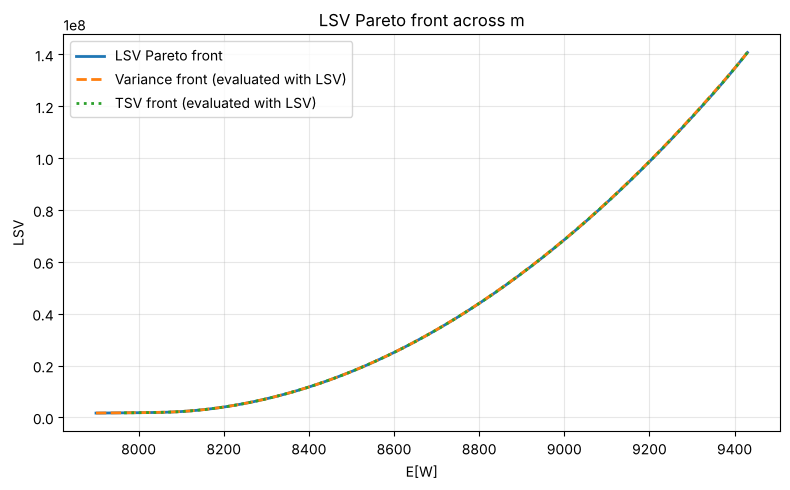

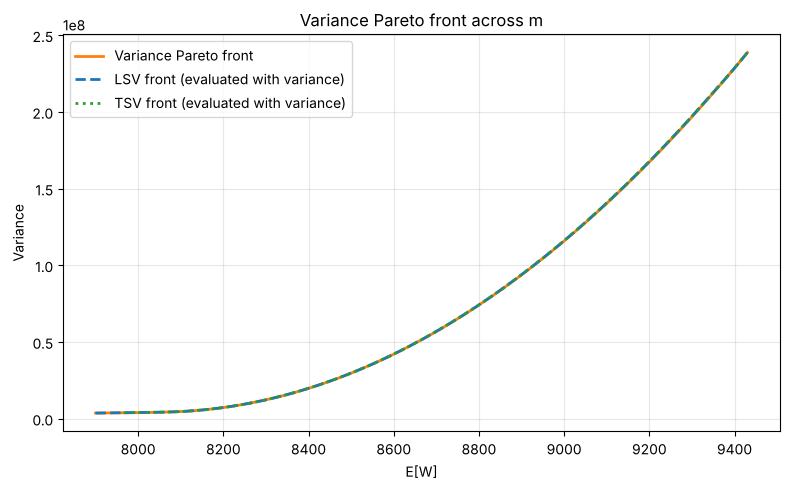

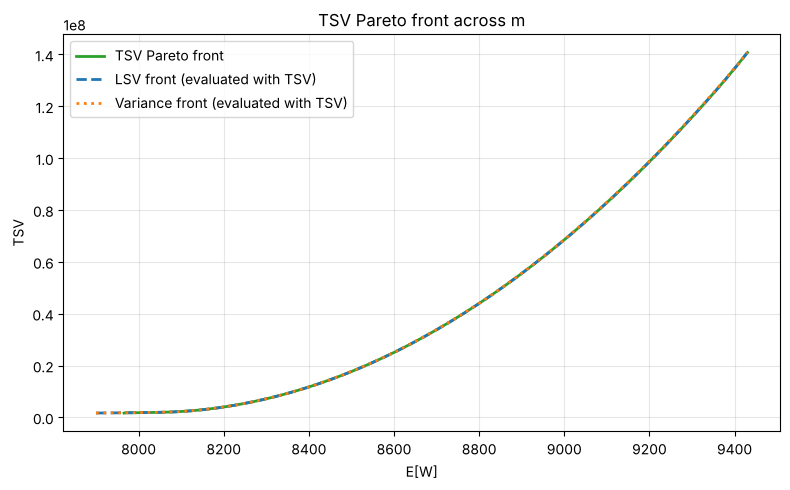

In [7]:

# Plot 1: LSV metric
fig_lsv_front, ax_lsv_front = plt.subplots(figsize=(8, 5))
ax_lsv_front.plot(x_lsv, y_lsv, color="tab:blue", linewidth=2, label="LSV Pareto front")
ax_lsv_front.plot(x_lsv_var_eval, y_lsv_var_eval, color="tab:orange", linestyle="--", linewidth=2,
                 label="Variance front (evaluated with LSV)")
ax_lsv_front.plot(x_lsv_tsv_eval, y_lsv_tsv_eval, color="tab:green", linestyle=":", linewidth=2,
                 label="TSV front (evaluated with LSV)")
ax_lsv_front.set_xlabel("E[W]")
ax_lsv_front.set_ylabel("LSV")
ax_lsv_front.set_title("LSV Pareto front across m")
ax_lsv_front.grid(alpha=0.3)
ax_lsv_front.legend()
plt.tight_layout()

# Plot 2: Variance metric
fig_var_front, ax_var_front = plt.subplots(figsize=(8, 5))
ax_var_front.plot(x_var, y_var, color="tab:orange", linewidth=2, label="Variance Pareto front")
ax_var_front.plot(x_var_lsv_eval, y_var_lsv_eval, color="tab:blue", linestyle="--", linewidth=2,
                 label="LSV front (evaluated with variance)")
ax_var_front.plot(x_var_tsv_eval, y_var_tsv_eval, color="tab:green", linestyle=":", linewidth=2,
                 label="TSV front (evaluated with variance)")
ax_var_front.set_xlabel("E[W]")
ax_var_front.set_ylabel("Variance")
ax_var_front.set_title("Variance Pareto front across m")
ax_var_front.grid(alpha=0.3)
ax_var_front.legend()
plt.tight_layout()

# Plot 3: TSV metric
fig_tsv_front, ax_tsv_front = plt.subplots(figsize=(8, 5))
ax_tsv_front.plot(x_tsv, y_tsv, color="tab:green", linewidth=2, label="TSV Pareto front")
ax_tsv_front.plot(x_tsv_lsv_eval, y_tsv_lsv_eval, color="tab:blue", linestyle="--", linewidth=2,
                 label="LSV front (evaluated with TSV)")
ax_tsv_front.plot(x_tsv_var_eval, y_tsv_var_eval, color="tab:orange", linestyle=":", linewidth=2,
                 label="Variance front (evaluated with TSV)")
ax_tsv_front.set_xlabel("E[W]")
ax_tsv_front.set_ylabel("TSV")
ax_tsv_front.set_title("TSV Pareto front across m")
ax_tsv_front.grid(alpha=0.3)
ax_tsv_front.legend()
plt.tight_layout()

plt.show()

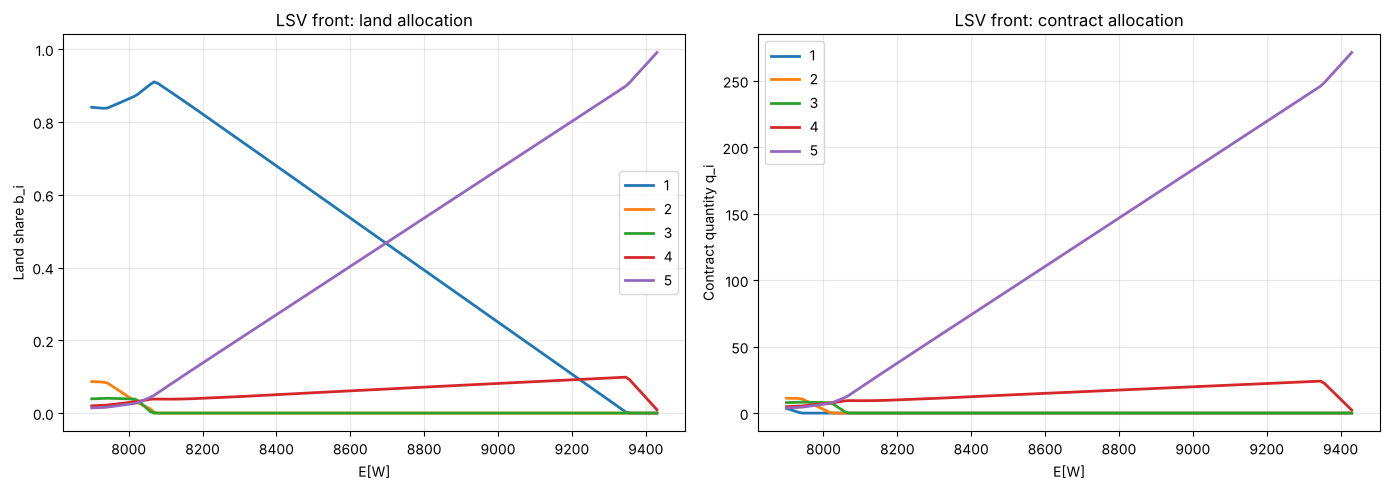

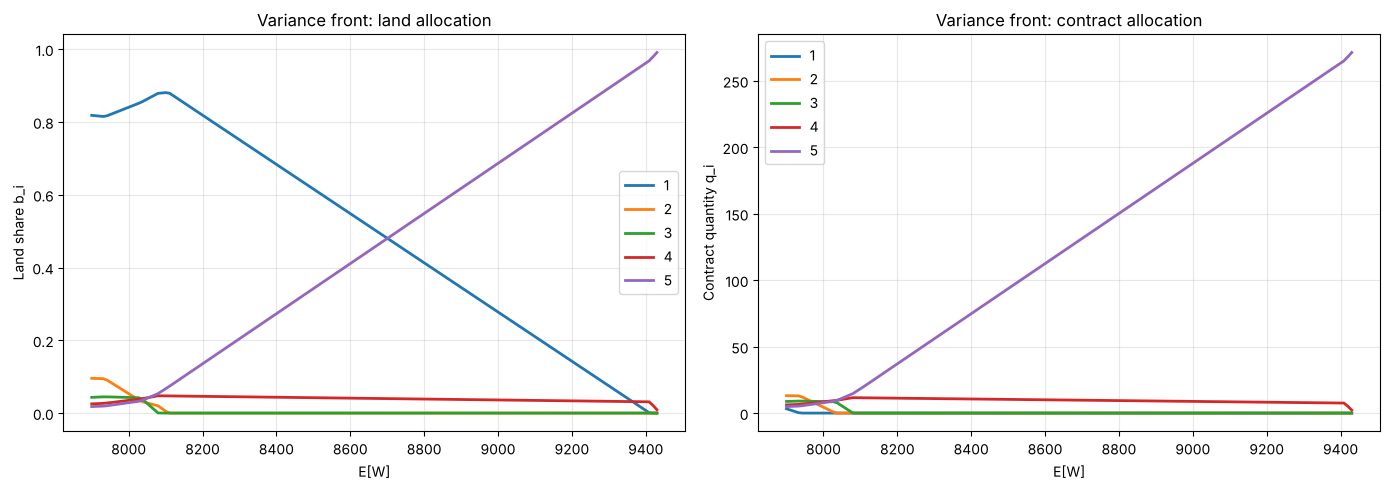

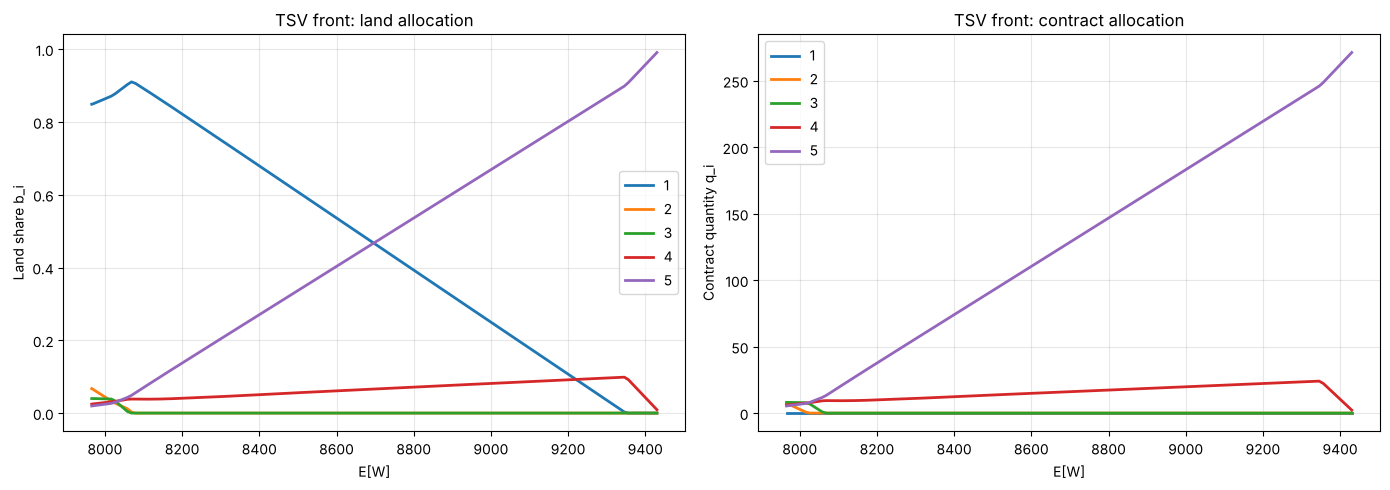

In [8]:
# Side-by-side land vs contract allocation plots for each front (LSV, variance, TSV)

fronts = {
    "LSV": lsv_front,
    "Variance": var_front,
    "TSV": tsv_front,
}

for metric_name, front in fronts.items():
    if not front:
        continue

    front = sorted(front, key=lambda item: item[0])  # sort by E[W]
    x = np.array([float(item[0]) for item in front], dtype=float)
    b_all = np.array([np.asarray(item[2], dtype=float) for item in front], dtype=float)
    q_all = np.array([np.asarray(item[3], dtype=float) for item in front], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    ax1, ax2 = axes

    # Left: land allocation
    for i, crop in enumerate(crop_names_multi):
        ax1.plot(x, b_all[:, i], linewidth=2, label=crop)
    ax1.set_xlabel("E[W]")
    ax1.set_ylabel("Land share b_i")
    ax1.set_title(f"{metric_name} front: land allocation")
    ax1.grid(alpha=0.3)
    ax1.legend(loc="best")

    # Right: contract allocation
    for i, crop in enumerate(crop_names_multi):
        ax2.plot(x, q_all[:, i], linewidth=2, label=crop)
    ax2.set_xlabel("E[W]")
    ax2.set_ylabel("Contract quantity q_i")
    ax2.set_title(f"{metric_name} front: contract allocation")
    ax2.grid(alpha=0.3)
    ax2.legend(loc="best")

    fig.tight_layout()
    plt.show()

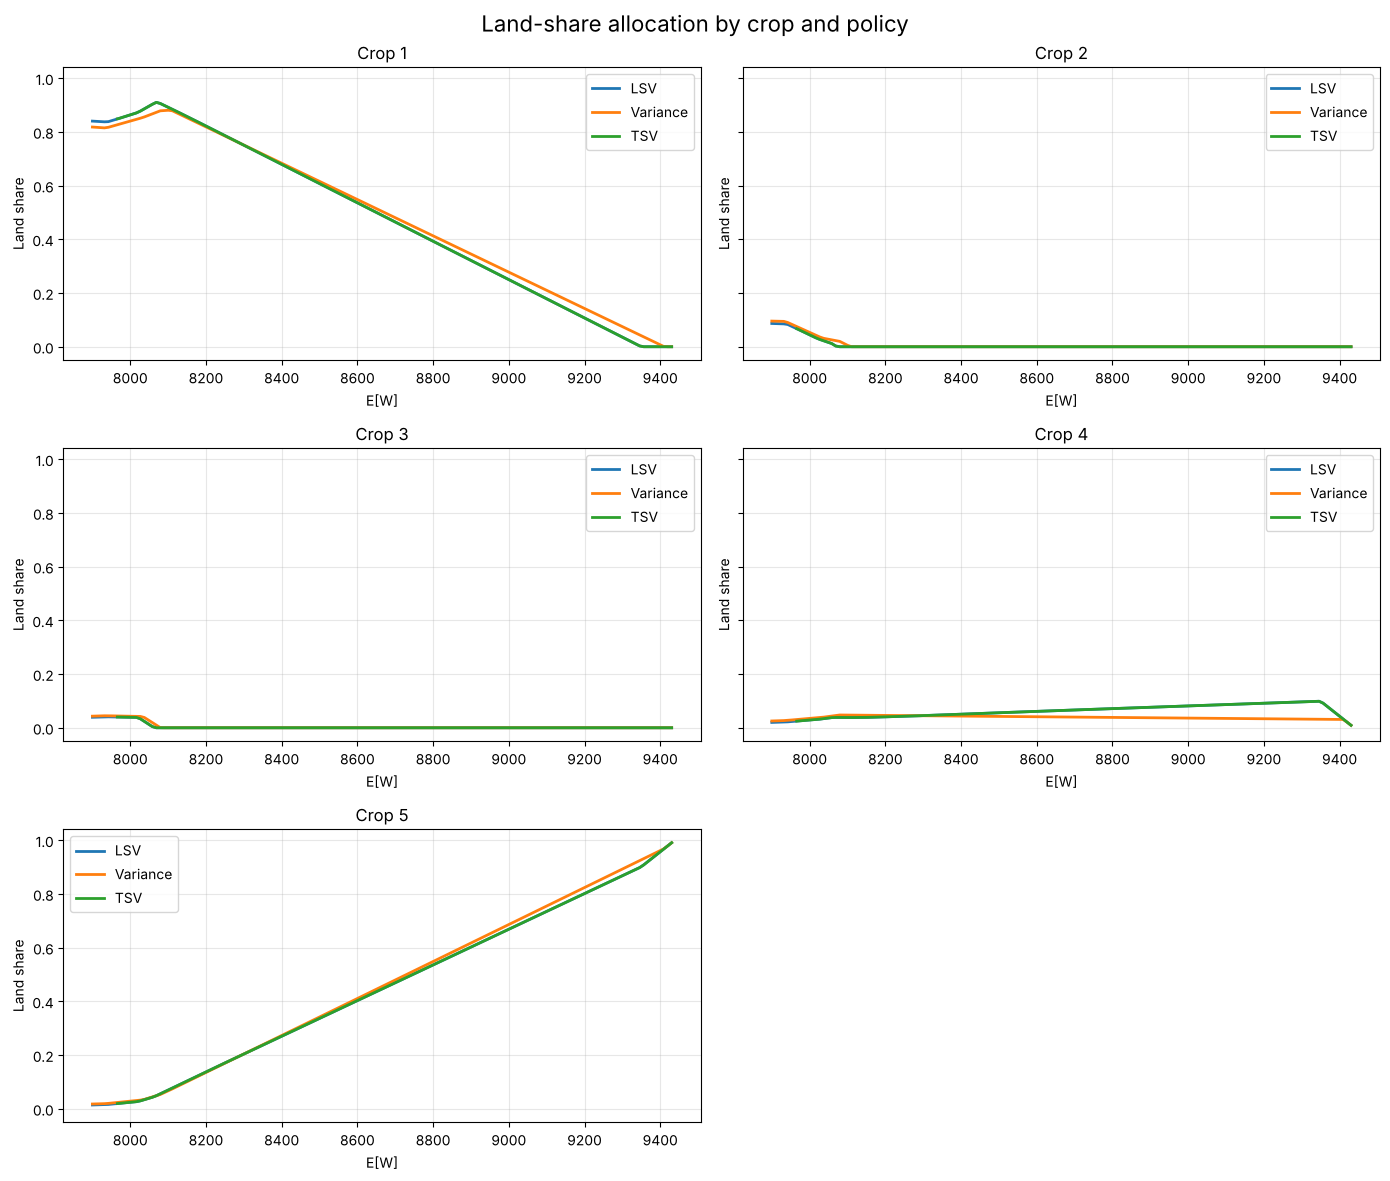

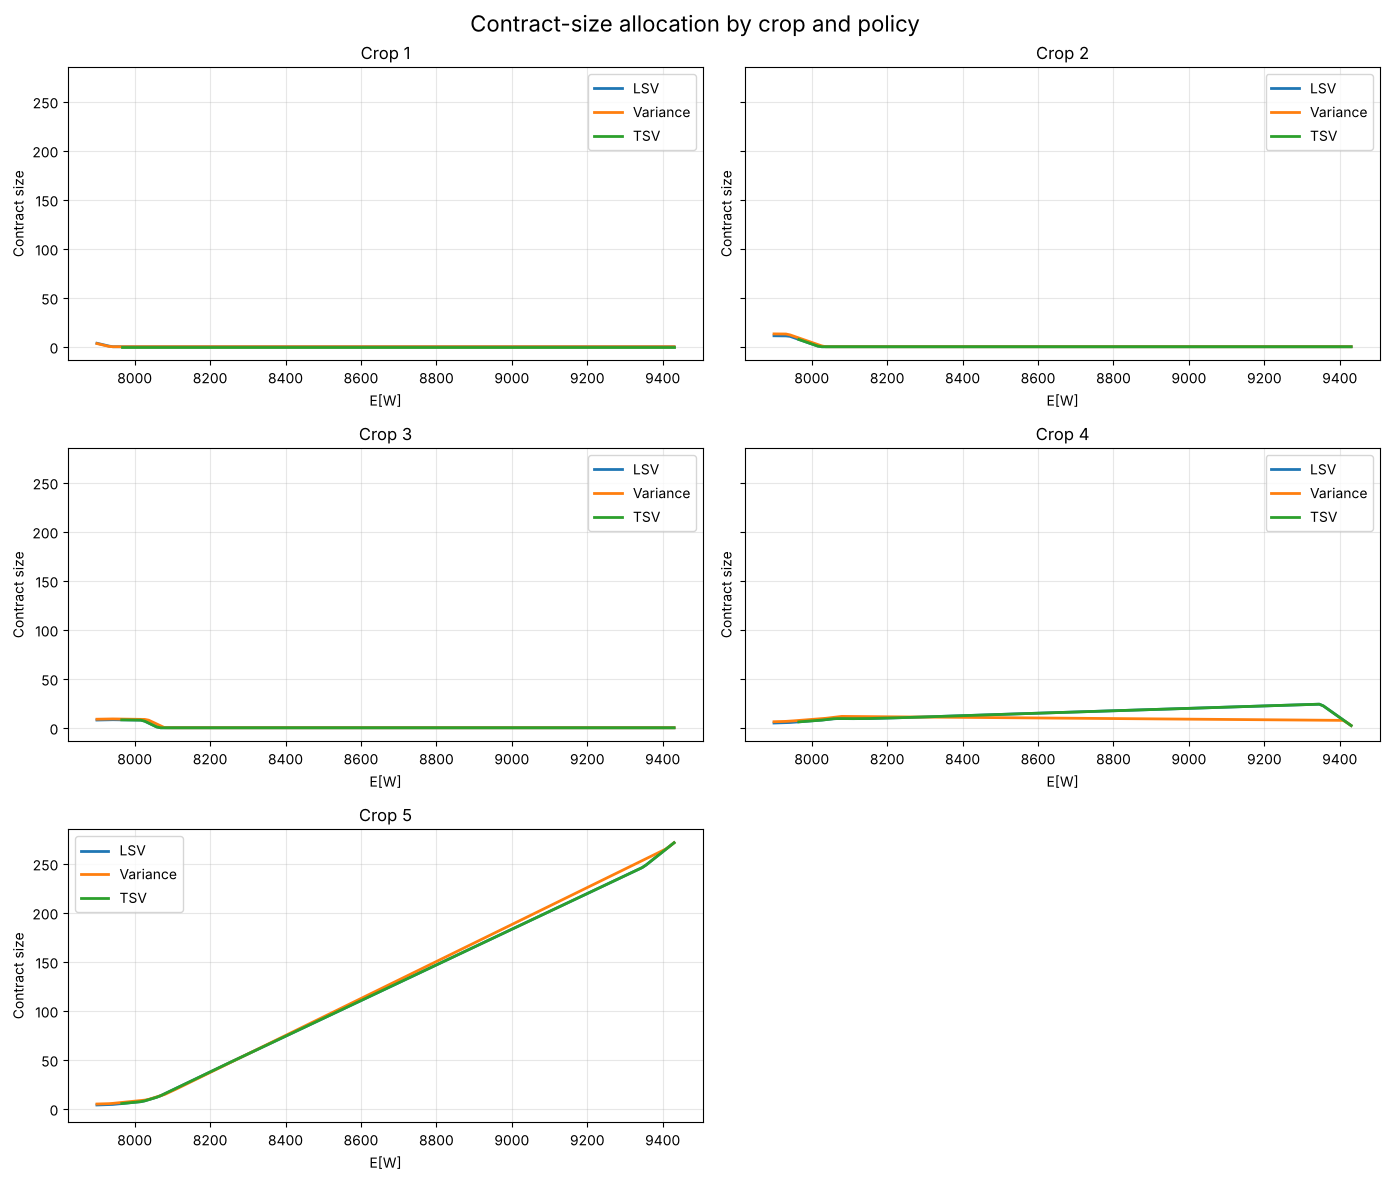

In [9]:
# Plot land share for each crop under each policy

policy_colors = {
    "LSV": "tab:blue",
    "Variance": "tab:orange",
    "TSV": "tab:green",
}

policy_fronts = {
    "LSV": lsv_front,
    "Variance": var_front,
    "TSV": tsv_front,
}

fig, axes = plt.subplots(
    nrows=int(np.ceil(n_products / 2)),
    ncols=2,
    figsize=(14, 4 * int(np.ceil(n_products / 2))),
    sharex=False,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()

for crop_idx, crop in enumerate(crop_names_multi):
    ax = axes[crop_idx]

    for policy, front in policy_fronts.items():
        if not front:
            continue

        front = sorted(front, key=lambda item: item[0])
        x_policy = np.array([item[0] for item in front])
        b_policy = np.array([item[2][crop_idx] for item in front])

        ax.plot(
            x_policy,
            b_policy,
            color=policy_colors[policy],
            linewidth=2,
            label=policy,
        )

    ax.set_title(f"Crop {crop}")
    ax.set_xlabel("E[W]")
    ax.set_ylabel("Land share")
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes[len(crop_names_multi):]:
    ax.set_visible(False)

fig.suptitle("Land-share allocation by crop and policy", fontsize=16)
fig.tight_layout()
plt.show()

# Plot contract size for each crop under each policy
fig, axes = plt.subplots(
    nrows=int(np.ceil(n_products / 2)),
    ncols=2,
    figsize=(14, 4 * int(np.ceil(n_products / 2))),
    sharex=False,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()

for crop_idx, crop in enumerate(crop_names_multi):
    ax = axes[crop_idx]

    for policy, front in policy_fronts.items():
        if not front:
            continue

        front = sorted(front, key=lambda item: item[0])
        x_policy = np.array([item[0] for item in front])
        q_policy = np.array([item[3][crop_idx] for item in front])

        ax.plot(
            x_policy,
            q_policy,
            color=policy_colors[policy],
            linewidth=2,
            label=policy,
        )

    ax.set_title(f"Crop {crop}")
    ax.set_xlabel("E[W]")
    ax.set_ylabel("Contract size")
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes[len(crop_names_multi):]:
    ax.set_visible(False)

fig.suptitle("Contract-size allocation by crop and policy", fontsize=16)
fig.tight_layout()
plt.show()